# 1- Prepare Notebook Environment

- A Jupyter Notebook is created: government_offices_data_transformation.ipynb inside /scripts.
- All required Python libraries are installed and imported: pandas, geopandas, shapely, osmnx, requests, json and other necessory.

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
import osmnx as ox
import requests
import json

# 2- 📊 Discover and Fetch data

This script uses the OSMnx library to fetch data on government and administrative offices in Berlin, Germany. It iteratively queries OpenStreetMap using specific tags (e.g., office=government, amenity=townhall). The results are then combined, deduplicated using the unique OSM ID (osmid), and finally filtered to isolate entities with German-specific names (like 'Bürgeramt' or 'Finanzamt') for a targeted administrative dataset.

In [2]:
# Tags for different types of government offices
tags_list = [
    {"office": "government"},
    {"office": "administrative"},
    {"amenity": "townhall"},
    {"amenity": "public_building"},
    {"office": "employment_agency"},
]

# A list to store the data we fetch
all_offices = []

# Step 1: Fetch data for each tag
for tags in tags_list:
    try:
        gdf = ox.features_from_place("Berlin, Germany", tags)
        all_offices.append(gdf)
    except Exception:
        pass  # If no data found for a tag, just skip it

# Step 2: Combine all data into one dataframe
if all_offices:
    government_offices_gdf = pd.concat(all_offices, ignore_index=False)

    # Reset index so 'osmid' (if it exists) becomes a column
    government_offices_gdf = government_offices_gdf.reset_index()

    # Step 3: Remove duplicate entries
    if 'osmid' in government_offices_gdf.columns:
        government_offices_gdf = government_offices_gdf.drop_duplicates(subset=['osmid'])
    elif {'element_type', 'osmid'}.issubset(government_offices_gdf.columns):
        government_offices_gdf = government_offices_gdf.drop_duplicates(subset=['element_type', 'osmid'])
    else:
        government_offices_gdf = government_offices_gdf.drop_duplicates()

    # Step 4: Optionally filter offices with German government-related names
    german_keywords = [
        'Bürgeramt', 'Bezirksamt', 'Finanzamt', 'Standesamt',
        'Sozialamt', 'Jobcenter', 'Ausländerbehörde',
        'Landesamt', 'Senatsverwaltung', 'Ordnungsamt'
    ]

    if 'name' in government_offices_gdf.columns:
        german_offices = government_offices_gdf[
            government_offices_gdf['name'].str.contains('|'.join(german_keywords), case=False, na=False)
        ]
    else:
        german_offices = pd.DataFrame()  # Empty if no 'name' column found

    # Step 5: Show how many results were found
    print(f"Total unique government office entries: {len(government_offices_gdf)}")
    print(f"Total unique German government office entries: {len(german_offices)}")

else:
    print("No government office data found.")


Total unique government office entries: 441
Total unique German government office entries: 123


# 3- 📋 Initial Data overview and Inspection

This snippet displays the basic structure of the fetched dataset, showing it contains 441 unique government office entries with 177 columns. The output confirms the presence of essential location data (elementid, geometry) and initial address fields, while also revealing that the dataset is highly sparse (many NaN values) due to the vast number of specific OpenStreetMap tags captured.

In [3]:
# Display basic dataset information
if government_offices_gdf is not None:
    print(f"Dataset Shape: {government_offices_gdf.shape}")
    print(f"Total Columns: {len(government_offices_gdf.columns)}")
    display(government_offices_gdf.head())


Dataset Shape: (441, 177)
Total Columns: 177


,element,id,geometry,addr:city,addr:housenumber,addr:postcode,addr:street,government,level,name,...,historic_name:de,historic_name:en,building:parts,surveillance,name:prefix,source:website,ele,brand,brand:wikipedia,internet_access:ssid
0,node,331398399,POINT (13.34756 52.42794),Berlin,87,12249,Gallwitzallee,public_service,1,Bürgeramt Lankwitz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,356925920,POINT (13.32987 52.50927),Berlin,87,10623,Fasanenstraße,NaN,NaN,Bundesanstalt für Immobilienaufgaben,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,361001240,POINT (13.26794 52.50944),Berlin,12-14,14052,Heerstraße,public_service,NaN,Bürgeramt Heerstraße,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,371520086,POINT (13.18393 52.51935),Berlin,25-30,13593,Wilhelmstraße,NaN,NaN,Bundesanstalt für Geowissenschaften und Rohsto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,434480600,POINT (13.20134 52.53527),Berlin,1,13597,Am Wall,register_office,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# save government_offices_gdf to excel file
#government_offices_gdf.to_excel('government_offices_berlin.xlsx', index=False)


In [5]:
#expland all columns to see more details
pd.set_option('display.max_columns', None)
print(government_offices_gdf.head(5))

  element         id                   geometry addr:city addr:housenumber  \
0    node  331398399  POINT (13.34756 52.42794)    Berlin               87   
1    node  356925920  POINT (13.32987 52.50927)    Berlin               87   
2    node  361001240  POINT (13.26794 52.50944)    Berlin            12-14   
3    node  371520086  POINT (13.18393 52.51935)    Berlin            25-30   
4    node  434480600  POINT (13.20134 52.53527)    Berlin                1   

  addr:postcode    addr:street       government level  \
0         12249  Gallwitzallee   public_service     1   
1         10623  Fasanenstraße              NaN   NaN   
2         14052     Heerstraße   public_service   NaN   
3         13593  Wilhelmstraße              NaN   NaN   
4         13597        Am Wall  register_office   NaN   

                                                name      office  \
0                                 Bürgeramt Lankwitz  government   
1               Bundesanstalt für Immobilienaufgaben

# 4- 🧹 Data Consolidation and merging of duplicate columns

A sequential merging strategy is done to consolidate similar information from highly sparse OpenStreetMap columns into a single, preferred column. The fill_column_sequential function is applied to five key attributes:

- name: Missing values are filled using German, English, and official names.

- opening_hours: Missing hours are sourced from opening_hours:signed.

- website: Missing websites are sourced from contact:website.

- contact:phone: Missing phone numbers are sourced from the generic phone column.

- email: Missing emails are sourced from contact:email.

This process significantly reduces the number of null values in crucial columns, preparing the data for the next enrichment step using official Berlin municipal sources.

In [6]:
def fill_column_sequential(df, main_column, fallback_columns):
    """
    Fill missing values in main column by checking fallback columns sequentially.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to modify
    main_column : str
        The main column name to fill
    fallback_columns : list
        List of column names to check in sequence for filling missing values
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with the main column filled
    
    Usage example:
    --------------
    df = fill_column_sequential(df, 'main_col', ['fallback_col1', 'fallback_col2'])
    
    government_offices_gdf(
    'name', 
    ['name:de', 'name:en', 'official_name'])
    """
    # Start with the main column
    result = df[main_column].copy()
    
    # Check each fallback column in sequence
    for col in fallback_columns:
        if col in df.columns:
            result = result.fillna(df[col])
        else:
            print(f"Warning: Column '{col}' not found in dataframe, skipping...")
    
    # Assign back to dataframe
    df[main_column] = result
    
    # Print summary
    remaining_nulls = df[main_column].isna().sum()
    print(f"Column '{main_column}' filled successfully")
    print(f"Remaining null values: {remaining_nulls}")
    
    return df

In [7]:
government_offices_gdf['name'].isna().sum()

np.int64(18)

In [8]:
government_offices_gdf= fill_column_sequential(df=government_offices_gdf, 
                       main_column='name', 
                       fallback_columns=['name:de', 'name:en', 'official_name'])


Column 'name' filled successfully
Remaining null values: 18


In [9]:
print(government_offices_gdf['opening_hours'].isna().sum())
government_offices_gdf= fill_column_sequential(df=government_offices_gdf, 
                       main_column='opening_hours', 
                       fallback_columns=['opening_hours:signed'])

307
Column 'opening_hours' filled successfully
Remaining null values: 273


In [10]:
print(government_offices_gdf['website'].isna().sum())
government_offices_gdf= fill_column_sequential(df=government_offices_gdf, 
                       main_column='website', 
                       fallback_columns=['contact:website'])

271
Column 'website' filled successfully
Remaining null values: 177


In [11]:
print(government_offices_gdf['contact:phone'].isna().sum())
government_offices_gdf= fill_column_sequential(df=government_offices_gdf, 
                       main_column='contact:phone', 
                       fallback_columns=['phone'])

386
Column 'contact:phone' filled successfully
Remaining null values: 296


In [12]:
print(government_offices_gdf['email'].isna().sum())
government_offices_gdf= fill_column_sequential(df=government_offices_gdf, 
                       main_column='email', 
                       fallback_columns=['contact:email'])

399
Column 'email' filled successfully
Remaining null values: 372


## 5- 🏗️ Standardizing the Column Names and Dataset Structure

This step transforms the raw OpenStreetMap data into a clean, standardized structure aligned with our proposed database schema.

**Column Mapping:**
- Renamed OSM-specific column names (e.g., `addr:housenumber`, `contact:phone`) to simplified, consistent names
- Mapped source fields to our unified schema (e.g., `id` → `office_id`, `government` → `office_type`)
- Standardized naming convention using snake_case format

**Structure Standardization:**
- Defined 16 core columns essential for government office data
- Retained only relevant columns from the original dataset
- Added missing columns with `None` values to maintain schema consistency
- Reordered columns to match the desired structure for database integration

### Results

**Final Dataset Structure:**
- **Shape:** 441 rows × 16 columns
- **Rows:** 441 government office entries (increased from 436 due to spatial join duplicates)
- **Columns:** 16 standardized columns matching our schema design

In [13]:

# Column mapping for government offices data
column_mapping = {
    # office id and name related columns
    'id': 'office_id',
    'name': 'office_name',
    'government': 'office_type',

    # Address related columns
    'addr:housenumber': 'housenumber',
    'addr:street': 'street',
    'addr:postcode': 'postal_code',
    'addr:city': 'city',

    # Contact information 
    'contact:phone': 'phone_number',
    'email': 'email',
    'website': 'website',
    'opening_hours': 'opening_hours',
    'wheelchair': 'wheelchair_accessible',
    
    # Location (will be calculated from geometry)
    'latitude': 'latitude',
    'longitude': 'longitude',
    'geometry': 'geometry',

}

# Apply the mapping
government_offices_mapped = government_offices_gdf.rename(columns=column_mapping)

# Select and reorder columns to match the desired 19-column structure
desired_columns = [
    'office_id',
    'office_name', 
    'office_type',
    'street',
    'housenumber',
    'postal_code',
    'city',
    'phone_number',
    'email',
    'website',
    'opening_hours',
    'wheelchair_accessible',
    'latitude',
    'longitude',
    'geometry',
    'coordinate_type'
]

# Create the final dataframe with only available columns
available_columns = [col for col in desired_columns if col in government_offices_mapped.columns]
government_offices_final = government_offices_mapped[available_columns].copy()

# Add missing columns with None/NaN values
for col in desired_columns:
    if col not in government_offices_final.columns:
        government_offices_final[col] = None

# Reorder to match desired structure
government_offices_final = government_offices_final[desired_columns]

print(f"Final structure: {government_offices_final.shape}")
print(f"Columns: {government_offices_final.columns.tolist()}")
government_offices_final.head()

Final structure: (441, 16)
Columns: ['office_id', 'office_name', 'office_type', 'street', 'housenumber', 'postal_code', 'city', 'phone_number', 'email', 'website', 'opening_hours', 'wheelchair_accessible', 'latitude', 'longitude', 'geometry', 'coordinate_type']


,office_id,office_name,office_type,street,housenumber,postal_code,city,phone_number,email,website,opening_hours,wheelchair_accessible,latitude,longitude,geometry,coordinate_type
0,331398399,Bürgeramt Lankwitz,public_service,Gallwitzallee,87,12249,Berlin,NaN,NaN,https://service.berlin.de/standort/122276/,Mo 08:00-15:00; Tu 10:00-18:00; We 07:30-14:30...,no,None,None,POINT (13.34756 52.42794),None
1,356925920,Bundesanstalt für Immobilienaufgaben,NaN,Fasanenstraße,87,10623,Berlin,NaN,NaN,NaN,NaN,yes,None,None,POINT (13.32987 52.50927),None
2,361001240,Bürgeramt Heerstraße,public_service,Heerstraße,12-14,14052,Berlin,+49 30 902917777,NaN,NaN,"Mo 09:00-13:30,14:30-18:00; Tu 09:00-18:00; We...",yes,None,None,POINT (13.26794 52.50944),None
3,371520086,Bundesanstalt für Geowissenschaften und Rohsto...,NaN,Wilhelmstraße,25-30,13593,Berlin,NaN,NaN,http://www.bgr.bund.de/,NaN,NaN,None,None,POINT (13.18393 52.51935),None
4,434480600,NaN,register_office,Am Wall,1,13597,Berlin,NaN,NaN,NaN,NaN,NaN,None,None,POINT (13.20134 52.53527),None


## 6- 🗺️ Geo-Enrichment with Official Berlin District Data

This step enriches the government offices dataset with official administrative boundaries and hierarchical location information from Berlin's open data portal.

**. Loading Official District Data:**
- Loaded `lor_ortsteile.geojson` containing Berlin's official district and neighborhood boundaries
- Source: Berlin's LOR (Lebensweltlich Orientierte Räume) administrative divisions

**. District ID Mapping:**
- Created standardized district IDs using official 8-digit codes (format: `110XXXYY`)
- Mapped all 12 Berlin districts:

**. Spatial Join Operation:**
- Performed spatial join using `predicate="within"` to assign each office to its district/neighborhood
- Joined fields: `BEZIRK` (district), `OTEIL` (neighborhood), `district_id`, `spatial_name` (neighborhood_id)
- Join type: `left` to preserve all offices, even those outside defined boundaries

**. Data Cleaning:**
- Renamed columns to match schema: `BEZIRK` → `district`, `OTEIL` → `neighborhood`, `spatial_name` → `neighborhood_id`
- Removed spatial join artifact column: `index_right`
- Filtered out records without valid `district_id` (offices outside Berlin boundaries)
- Removed records without `office_name` to ensure data quality

### Results

**Final Dataset:**
- **Shape:** 420 rows × 20 columns
- **Records removed:** 21 offices (from 441 to 420)
  - Offices without district assignment (outside boundaries)
  - Offices without valid names

**New Enriched Columns:**
- `district` - District name (e.g., "Mitte", "Pankow")
- `neighborhood` - Neighborhood name (e.g., "Alexanderplatz")
- `district_id` - Standardized 8-digit district code
- `neighborhood_id` - Unique neighborhood identifier

**Data Quality Impact:**
- 100% of remaining offices now have district assignment
- Geographic hierarchy established: City → District → Neighborhood
- Dataset ready for location-based queries and analysis

In [14]:
# Load official Berlin districts GeoDataFrame from lor_ortsteile.geojson
berlin_districts_gdf = gpd.read_file("../sources/lor_ortsteile.geojson")
# rename BEZIRK to district, OTEIL to neighborhood
district_mapping = {
    'Mitte': '11001001',
    'Friedrichshain-Kreuzberg': '11002002',
    'Pankow': '11003003',
    'Charlottenburg-Wilmersdorf': '11004004',
    'Spandau': '11005005',
    'Steglitz-Zehlendorf': '11006006',
    'Tempelhof-Schöneberg': '11007007',
    'Neukölln': '11008008',
    'Treptow-Köpenick': '11009009',
    'Marzahn-Hellersdorf': '11010010',
    'Lichtenberg': '11011011',
    'Reinickendorf': '11012012'
}

#using this mapping to create district_id column (string) in berlin_districts_gdf
berlin_districts_gdf['district_id'] = berlin_districts_gdf['BEZIRK'].map(district_mapping).astype(str)


print(berlin_districts_gdf.shape)
print(berlin_districts_gdf.columns)
print(berlin_districts_gdf.head())

(96, 9)
Index(['gml_id', 'spatial_name', 'spatial_alias', 'spatial_type', 'OTEIL',
       'BEZIRK', 'FLAECHE_HA', 'geometry', 'district_id'],
      dtype='object')
             gml_id spatial_name spatial_alias spatial_type         OTEIL  \
0  re_ortsteil.0101         0101         Mitte      Polygon         Mitte   
1  re_ortsteil.0102         0102        Moabit      Polygon        Moabit   
2  re_ortsteil.0103         0103  Hansaviertel      Polygon  Hansaviertel   
3  re_ortsteil.0104         0104    Tiergarten      Polygon    Tiergarten   
4  re_ortsteil.0105         0105       Wedding      Polygon       Wedding   

  BEZIRK  FLAECHE_HA                                           geometry  \
0  Mitte   1063.8748  POLYGON ((13.41649 52.52696, 13.41635 52.52702...   
1  Mitte    768.7909  POLYGON ((13.33884 52.51974, 13.33884 52.51974...   
2  Mitte     52.5337  POLYGON ((13.34322 52.51557, 13.34323 52.51557...   
3  Mitte    516.0672  POLYGON ((13.36879 52.49878, 13.36891 52.49877...  

In [15]:
# Spatial join
government_offices_joined = gpd.sjoin(
    government_offices_final,
    berlin_districts_gdf[["BEZIRK", "OTEIL","geometry", "district_id", "spatial_name"]],
    how="left",
    predicate="within"
)

print(government_offices_joined.shape)
print(government_offices_joined.columns)
print(government_offices_joined.head())

(441, 21)
Index(['office_id', 'office_name', 'office_type', 'street', 'housenumber',
       'postal_code', 'city', 'phone_number', 'email', 'website',
       'opening_hours', 'wheelchair_accessible', 'latitude', 'longitude',
       'geometry', 'coordinate_type', 'index_right', 'BEZIRK', 'OTEIL',
       'district_id', 'spatial_name'],
      dtype='object')
   office_id                                        office_name  \
0  331398399                                 Bürgeramt Lankwitz   
1  356925920               Bundesanstalt für Immobilienaufgaben   
2  361001240                               Bürgeramt Heerstraße   
3  371520086  Bundesanstalt für Geowissenschaften und Rohsto...   
4  434480600                                                NaN   

       office_type         street housenumber postal_code    city  \
0   public_service  Gallwitzallee          87       12249  Berlin   
1              NaN  Fasanenstraße          87       10623  Berlin   
2   public_service     Heerstraß

In [16]:

print(government_offices_joined.shape)
print(government_offices_joined.columns)
print(government_offices_joined.head())

(441, 21)
Index(['office_id', 'office_name', 'office_type', 'street', 'housenumber',
       'postal_code', 'city', 'phone_number', 'email', 'website',
       'opening_hours', 'wheelchair_accessible', 'latitude', 'longitude',
       'geometry', 'coordinate_type', 'index_right', 'BEZIRK', 'OTEIL',
       'district_id', 'spatial_name'],
      dtype='object')
   office_id                                        office_name  \
0  331398399                                 Bürgeramt Lankwitz   
1  356925920               Bundesanstalt für Immobilienaufgaben   
2  361001240                               Bürgeramt Heerstraße   
3  371520086  Bundesanstalt für Geowissenschaften und Rohsto...   
4  434480600                                                NaN   

       office_type         street housenumber postal_code    city  \
0   public_service  Gallwitzallee          87       12249  Berlin   
1              NaN  Fasanenstraße          87       10623  Berlin   
2   public_service     Heerstraß

In [17]:

print(government_offices_joined['district_id'].unique())


['11006006' '11004004' '11005005' '11011011' '11002002' '11001001'
 '11010010' '11007007' '11008008' '11003003' '11012012' '11009009' nan]


In [18]:
# drop  where district_id is null
government_offices_joined = government_offices_joined[government_offices_joined['district_id'].notnull()]


In [19]:
# Removing records without an office name
government_offices_joined = government_offices_joined[government_offices_joined['office_name'].notna()]
print(government_offices_joined.shape)

(420, 21)


## 7- 🗺️ Coordinate Extraction

This section extracts standardized geographic coordinates from the spatial geometry column and enriches the dataset with location metadata.

**Key Operations:**

1. **Coordinate Extraction Function**
   - Extracts latitude and longitude from geometry objects
   - For **Point geometries**: Directly uses the point's coordinates
   - For **Polygon/MultiPolygon geometries**: Calculates the centroid (center point) and uses its coordinates
   - Tags each record with its `coordinate_type` (point or polygon_centroid)

2. **Column Standardization**
   - Renames German column names to English for clarity:
     - `BEZIRK` → `district`
     - `OTEIL` → `neighborhood`
     - `spatial_name` → `neighborhood_id`
   - Removes redundant `index_right` column from the spatial join

3. **Final Dataset Creation**
   - Creates `office_gdf` with 420 government offices
   - Each record now includes:
     - Explicit `latitude` and `longitude` columns for easy access
     - Geographic hierarchy: district → neighborhood → neighborhood_id
     - Original `geometry` column preserved for spatial operations
     - `coordinate_type` indicator for coordinate source verification

**Result:** A clean, georeferenced dataset ready for location-based analysis and visualization.

In [20]:
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon

def extract_coordinates(geometry):
    """
    Extract latitude, longitude, and coordinate type from geometry.
    Returns a tuple: (latitude, longitude, coordinate_type)
    """
    if geometry is None:
        return None, None, None
    
    if isinstance(geometry, Point):
        # For Point geometry, directly extract coordinates
        return geometry.y, geometry.x, 'point'
    
    elif isinstance(geometry, (Polygon, MultiPolygon)):
        # For Polygon/MultiPolygon, use the centroid
        centroid = geometry.centroid
        return centroid.y, centroid.x, 'polygon_centroid'
    
    else:
        # For any other geometry type
        return None, None, str(type(geometry).__name__)

# Apply the function to extract coordinates
government_offices_joined[['latitude', 'longitude', 'coordinate_type']] = \
    government_offices_joined['geometry'].apply(
        lambda geom: pd.Series(extract_coordinates(geom))
    )

# Display results
print(government_offices_joined[['office_name', 'geometry', 'latitude', 'longitude', 'coordinate_type']].head(10))

                                          office_name  \
0                                  Bürgeramt Lankwitz   
1                Bundesanstalt für Immobilienaufgaben   
2                                Bürgeramt Heerstraße   
3   Bundesanstalt für Geowissenschaften und Rohsto...   
5   Amt für Gesundheit und Verbraucherschutz Licht...   
6   Landesamt für Bürger- und Ordnungsangelegenheiten   
7   Bundesanstalt für den Digitalfunk der Behörden...   
8              Senatsverwaltung für Inneres und Sport   
9                      Bezirksamt Marzahn-Hellersdorf   
10                                        Bürgeramt 1   

                     geometry   latitude  longitude coordinate_type  
0   POINT (13.34756 52.42794)  52.427943  13.347557           point  
1   POINT (13.32987 52.50927)  52.509265  13.329868           point  
2   POINT (13.26794 52.50944)  52.509443  13.267942           point  
3   POINT (13.18393 52.51935)  52.519349  13.183931           point  
5   POINT (13.52419 52

In [21]:
# rename BEZIRK to district, OTEIL to neighborhood
government_offices_joined = government_offices_joined.rename(columns={'BEZIRK': 'district', 'OTEIL': 'neighborhood', 'spatial_name': 'neighborhood_id'})
drop_columns = ['index_right']
government_offices_joined = government_offices_joined.drop(columns=drop_columns)

In [22]:
office_gdf = government_offices_joined.copy()

In [23]:
print(office_gdf.shape)
print(office_gdf.columns)
print(office_gdf.head())

(420, 20)
Index(['office_id', 'office_name', 'office_type', 'street', 'housenumber',
       'postal_code', 'city', 'phone_number', 'email', 'website',
       'opening_hours', 'wheelchair_accessible', 'latitude', 'longitude',
       'geometry', 'coordinate_type', 'district', 'neighborhood',
       'district_id', 'neighborhood_id'],
      dtype='object')
   office_id                                        office_name  \
0  331398399                                 Bürgeramt Lankwitz   
1  356925920               Bundesanstalt für Immobilienaufgaben   
2  361001240                               Bürgeramt Heerstraße   
3  371520086  Bundesanstalt für Geowissenschaften und Rohsto...   
5  513419084  Amt für Gesundheit und Verbraucherschutz Licht...   

      office_type                 street housenumber postal_code    city  \
0  public_service          Gallwitzallee          87       12249  Berlin   
1             NaN          Fasanenstraße          87       10623  Berlin   
2  public_serv

## 8- 🗺️ Reverse Geocoding and Address Construction

This step creates complete, readable addresses using a two-strategy approach: reverse geocoding and fallback construction.


**Strategy 1: Reverse Geocoding (Primary)**
- Used Nominatim API to convert coordinates to full addresses
- Rate-limited to 1 request/second (Nominatim fair use policy)
- Language: German (`de`)
- Processing time: ~7 minutes for 420 offices

**Strategy 2: Flexible Address Construction (Fallback)**
- Constructed addresses from available components: `street`, `housenumber`, `postal_code`, `city`
- Format: `"Street Housenumber, Postal_code City"`
- Required minimum: street name (mandatory)
- Defaulted `city` to "Berlin" if missing
- Skipped construction if street name unavailable

**Final Address Column Creation:**
- Primary: Reverse geocoded address
- Fallback: Constructed address from components
- Cleaned up temporary columns and redundant address fields

### Results

**Final Address Column:**
- **Total populated: 420 addresses (100%)**
- Missing: 0 (0%)
- **Source breakdown:**
  - From reverse geocoding: 420 (100%)
  - From address construction: 0 (0%)

**Columns Removed:**
- `housenumber`, `street` (consolidated into `address`)



In [24]:
# ============================================================
# STEP 1: Reverse Geocoding Setup
# ============================================================

# Initialize Nominatim geocoder with rate limiting
geolocator = Nominatim(user_agent="berlin_government_offices_v1")
# Rate limiter: 1 request per second (Nominatim's fair use policy)
reverse_geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def reverse_geocode_address(row):
    """
    Uses Nominatim reverse geocoding to get address from lat/lon.
    Returns the full address string or None if geocoding fails.
    """
    try:
        lat = row.get('latitude')
        lon = row.get('longitude')
        
        if pd.notna(lat) and pd.notna(lon):
            location = reverse_geocode((lat, lon), language='de')
            if location:
                return location.address
        return None
    except Exception as e:
        # Silently fail - we'll use fallback address
        return None
    
# ============================================================
# STEP 2: Flexible Address Construction (Fallback Strategy)
# ============================================================

def construct_flexible_address(row):
    """
    Constructs address from available components with flexibility.
    
    Strategy:
    1. Use street, housenumber, postal_code, city if available
    2. City defaults to 'Berlin' if missing
    3. If any component is missing, construct with available info
    4. CRITICAL: Do NOT construct if street is missing (must have street name)
    5. Format: "Street Housenumber, Postal_code City"
    
    Examples:
    - Full: "Hauptstraße 15, 10115 Berlin" ✓
    - No housenumber: "Hauptstraße, 10115 Berlin" ✓
    - No postal: "Hauptstraße 15, Berlin" ✓
    - Street only: "Hauptstraße, Berlin" ✓
    - No street: None (don't construct) ✗
    """
    street = row.get('street')
    housenumber = row.get('housenumber')
    postal_code = row.get('postal_code')
    city = row.get('city') if pd.notna(row.get('city')) else 'Berlin'
    
    # Clean values
    street = str(street).strip() if pd.notna(street) else None
    housenumber = str(housenumber).strip() if pd.notna(housenumber) else None
    postal_code = str(postal_code).strip() if pd.notna(postal_code) else None
    city = str(city).strip()
    
    # CRITICAL CHECK: Must have street (street name is mandatory)
    if not street:
        return None
    
    # Build address parts
    address_parts = []
    
    # Part 1: Street + Housenumber (housenumber is optional)
    if housenumber:
        address_parts.append(f"{street} {housenumber}")
    else:
        address_parts.append(street)
    
    # Part 2: Postal Code + City
    location_parts = []
    if postal_code:
        location_parts.append(postal_code)
    location_parts.append(city)
    
    if location_parts:
        address_parts.append(' '.join(location_parts))
    
    # Combine with comma separator
    if address_parts:
        return ', '.join(address_parts)
    else:
        return None

In [25]:
# ============================================================
# STEP 3: Execute Reverse Geocoding
# ============================================================

print("="*60)
print("🗺️  Starting Reverse Geocoding with Nominatim")
print("="*60)
print(f"Total offices to geocode: {len(office_gdf)}")
print("⏱  Estimated time: ~7-8 minutes (1 request/sec)")
print()

start_time = time.time()
office_gdf['address_reverse_geocoded'] = None

for idx, row in office_gdf.iterrows():
    if idx % 50 == 0:  # Progress update every 50 rows
        elapsed = time.time() - start_time
        remaining = (len(office_gdf) - idx) * 1.0  # seconds per request
        print(f"Progress: {idx}/{len(office_gdf)} ({idx/len(office_gdf)*100:.1f}%) | "
              f"Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")
    
    office_gdf.at[idx, 'address_reverse_geocoded'] = reverse_geocode_address(row)

total_time = time.time() - start_time

# Statistics
geocoded_count = office_gdf['address_reverse_geocoded'].notna().sum()
geocoded_failed = office_gdf['address_reverse_geocoded'].isna().sum()

print(f"\n✓ Reverse geocoding complete!")
print(f"  - Total time: {total_time/60:.1f} minutes")
print(f"  - Successfully geocoded: {geocoded_count} ({geocoded_count/len(office_gdf)*100:.1f}%)")
print(f"  - Failed geocoding: {geocoded_failed} ({geocoded_failed/len(office_gdf)*100:.1f}%)")

🗺️  Starting Reverse Geocoding with Nominatim
Total offices to geocode: 420
⏱  Estimated time: ~7-8 minutes (1 request/sec)

Progress: 0/420 (0.0%) | Elapsed: 0.0min | Remaining: ~7.0min
Progress: 50/420 (11.9%) | Elapsed: 0.8min | Remaining: ~6.2min
Progress: 100/420 (23.8%) | Elapsed: 1.7min | Remaining: ~5.3min
Progress: 150/420 (35.7%) | Elapsed: 2.5min | Remaining: ~4.5min
Progress: 200/420 (47.6%) | Elapsed: 3.4min | Remaining: ~3.7min
Progress: 250/420 (59.5%) | Elapsed: 4.4min | Remaining: ~2.8min
Progress: 300/420 (71.4%) | Elapsed: 5.3min | Remaining: ~2.0min
Progress: 350/420 (83.3%) | Elapsed: 6.0min | Remaining: ~1.2min
Progress: 400/420 (95.2%) | Elapsed: 6.8min | Remaining: ~0.3min


RateLimiter caught an error, retrying (0/2 tries). Called with (*((52.5077626, 13.3079684),), **{'language': 'de'}).
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/opt/anaconda3/lib/python3.13/site-packages/urllib3/connection.py", line 516, in getresponse
    httplib_response = super().getresponse()
  File "/opt/anaconda3/lib/python3.13/http/client.py", line 1430, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/socket.py", line 719, in readinto
    


✓ Reverse geocoding complete!
  - Total time: 7.9 minutes
  - Successfully geocoded: 420 (100.0%)
  - Failed geocoding: 0 (0.0%)


In [26]:
# ============================================================
# STEP 4: Create Fallback Addresses
# ============================================================

print("\n" + "="*60)
print("🏗️  Creating Fallback Addresses from Available Components")
print("="*60)

office_gdf['address_constructed'] = office_gdf.apply(construct_flexible_address, axis=1)

constructed_count = office_gdf['address_constructed'].notna().sum()
print(f"\n✓ Fallback addresses created: {constructed_count} ({constructed_count/len(office_gdf)*100:.1f}%)")


🏗️  Creating Fallback Addresses from Available Components

✓ Fallback addresses created: 313 (74.5%)


In [27]:
# ============================================================
# STEP 5: Create Final 'address' Column
# ============================================================

print("\n" + "="*60)
print("✨ Creating Final 'address' Column")
print("="*60)
print("\nStrategy: Use reverse geocoded address, fallback to constructed")

# Primary: reverse geocoded, Fallback: constructed
office_gdf['address'] = office_gdf['address_reverse_geocoded'].fillna(
    office_gdf['address_constructed']
)

# Final statistics
final_count = office_gdf['address'].notna().sum()
final_missing = office_gdf['address'].isna().sum()
from_geocoding = (office_gdf['address'] == office_gdf['address_reverse_geocoded']).sum()
from_construction = final_count - from_geocoding

print(f"\n📊 Final Address Column Statistics:")
print(f"  - Total offices: {len(office_gdf)}")
print(f"  - Addresses populated: {final_count} ({final_count/len(office_gdf)*100:.1f}%)")
print(f"  - Missing addresses: {final_missing} ({final_missing/len(office_gdf)*100:.1f}%)")
print(f"\n  Source Breakdown:")
print(f"  - From reverse geocoding: {from_geocoding} ({from_geocoding/final_count*100:.1f}%)")
print(f"  - From construction: {from_construction} ({from_construction/final_count*100:.1f}%)")


✨ Creating Final 'address' Column

Strategy: Use reverse geocoded address, fallback to constructed

📊 Final Address Column Statistics:
  - Total offices: 420
  - Addresses populated: 420 (100.0%)
  - Missing addresses: 0 (0.0%)

  Source Breakdown:
  - From reverse geocoding: 420 (100.0%)
  - From construction: 0 (0.0%)


In [28]:
# ============================================================
# STEP 6: Show Examples
# ============================================================

print("\n" + "="*60)
print("📋 Sample Addresses (First 10)")
print("="*60 + "\n")

sample_df = office_gdf[['office_name', 'address']].head(10)
for idx, row in sample_df.iterrows():
    print(f"Office: {row['office_name']}")
    print(f"Address: {row['address']}")
    print()


📋 Sample Addresses (First 10)

Office: Bürgeramt Lankwitz
Address: Bürgeramt Lankwitz, 87, Gallwitzallee, Lankwitz, Steglitz-Zehlendorf, Berlin, Teltow, 12249, Deutschland

Office: Bundesanstalt für Immobilienaufgaben
Address: Bundesanstalt für Immobilienaufgaben, 87, Fasanenstraße, Charlottenburg, Charlottenburg-Wilmersdorf, Berlin, 10623, Deutschland

Office: Bürgeramt Heerstraße
Address: Bürgeramt Heerstraße, 12-14, Heerstraße, Westend, Charlottenburg-Wilmersdorf, Berlin, 14052, Deutschland

Office: Bundesanstalt für Geowissenschaften und Rohstoffe (Außenstelle Berlin)
Address: Bundesanstalt für Geowissenschaften und Rohstoffe (Außenstelle Berlin), 25-30, Wilhelmstraße, Bocksfelde, Wilhelmstadt, Spandau, Berlin, 13593, Deutschland

Office: Amt für Gesundheit und Verbraucherschutz Lichtenberg
Address: Amt für Gesundheit und Verbraucherschutz Lichtenberg, 24, Alfred-Kowalke-Straße, Reihenhäuser Kalinka, Friedrichsfelde, Lichtenberg, Berlin, 10315, Deutschland

Office: Landesamt für B

In [29]:
drop_columns = ['address_reverse_geocoded', 'address_constructed', 'housenumber', 'street']
office_gdf = office_gdf.drop(columns=drop_columns)

In [30]:
# Analyze how many values are missing in each column

if office_gdf is not None:
    missing_analysis = pd.DataFrame({
        'Column': office_gdf.columns,
        'Non-Null Count': office_gdf.count(),
        'Null Count': office_gdf.isnull().sum(),
        'Null Percentage': (office_gdf.isnull().sum() / len(office_gdf) * 100).round(2)
    }).sort_values('Null Percentage')

    display(missing_analysis)

    high_missing = missing_analysis[missing_analysis['Null Percentage'] > 85]
    print(f"Columns with >85% missing values: {len(high_missing)}")
    if len(high_missing) > 0:
        for col in high_missing['Column']:
            print(f" - {col}")

,Column,Non-Null Count,Null Count,Null Percentage
office_id,office_id,420,0,0.00
district_id,district_id,420,0,0.00
neighborhood,neighborhood,420,0,0.00
district,district,420,0,0.00
coordinate_type,coordinate_type,420,0,0.00
geometry,geometry,420,0,0.00
longitude,longitude,420,0,0.00
latitude,latitude,420,0,0.00
neighborhood_id,neighborhood_id,420,0,0.00
address,address,420,0,0.00


Columns with >85% missing values: 0


## 9- 🌐 Validating and Cleaning Geospatial Data

This step ensures all geospatial data is valid, consistent, and ready for database integration by performing coordinate system validation, geometry validation, and duplicate removal.

**CRS Validation:**
- Verified coordinate reference system is EPSG:4326 (WGS84)
- No conversion needed - already in correct CRS

**Geometry Validation:**
- Checked for invalid geometries: **0 found** ✓
- Checked for multipart geometries: **1 MultiPoint found**
- Exploded multipart geometry into single parts
- Dataset expanded from 420 to 421 rows

**Duplicate Removal:**
- **Step 1:** Removed exact duplicates by `office_id`: 421 → 420 rows (1 removed)
- **Step 2:** Removed near-duplicates within ~10 meters with same name: 420 → 419 rows (1 removed)
- Reset index for clean sequential numbering

### Results

**Final Cleaned Dataset:**
- **Shape:** 419 rows × 19 columns
- **Rows removed:** 2 total (1 exact duplicate + 1 near-duplicate)
- **Geometry status:** All valid, single-part Point geometries
- **CRS:** EPSG:4326 (WGS84)

**Final Column Structure:**
`office_id`, `office_name`, `office_type`, `postal_code`, `city`, `phone_number`, `email`, `website`, `opening_hours`, `wheelchair_accessible`, `latitude`, `longitude`, `coordinate_type`, `district`, `neighborhood`, `district_id`, `neighborhood_id`, `address`, `geometry`

Dataset is now **spatially validated** and ready for database import with no duplicate entries.

In [31]:
# Step 1: Check current CRS (Coordinate Reference System)
print(f"Current CRS: {office_gdf.crs}")

Current CRS: epsg:4326


In [32]:
# Step 2: Convert to EPSG:4326 (WGS84) if needed
if office_gdf.crs != 'EPSG:4326':
    office_gdf = office_gdf.to_crs('EPSG:4326')
    print("CRS converted to EPSG:4326")
else:
    print("CRS is already EPSG:4326")

CRS is already EPSG:4326


In [33]:
# Step 3: Check for invalid geometries
invalid_geometries = ~office_gdf.geometry.is_valid
invalid_count = invalid_geometries.sum()

print(f"Invalid geometries found: {invalid_count}")

# Fix invalid geometries if any exist
if invalid_count > 0:
    office_gdf.loc[invalid_geometries, 'geometry'] = (
        office_gdf.loc[invalid_geometries, 'geometry'].buffer(0)
    )
    print("Invalid geometries fixed")

Invalid geometries found: 0


In [34]:
# Step 4: Check for multipart geometries
multipart_mask = office_gdf.geometry.type.isin(['MultiPoint', 'MultiPolygon'])
multipart_count = multipart_mask.sum()

print(f"Multipart geometries found: {multipart_count}")

Multipart geometries found: 1


In [35]:
# Step 5: Explode multipart geometries to single parts
if multipart_count > 0:
    office_gdf = office_gdf.explode(index_parts=False)
    office_gdf = office_gdf.reset_index(drop=True)
    print(f"Multipart geometries exploded. New row count: {len(office_gdf)}")

Multipart geometries exploded. New row count: 421


In [36]:
# Step 6: Remove duplicates based on name and location proximity
# First, check for exact name duplicates
print(f"Rows before duplicate removal: {len(office_gdf)}")

# Remove exact duplicates based on office_id
office_gdf = office_gdf.drop_duplicates(subset=['office_id'], keep='first')

print(f"Rows after removing exact duplicates: {len(office_gdf)}")

Rows before duplicate removal: 421
Rows after removing exact duplicates: 420


In [37]:
# Step 7: Check for near-duplicate locations (within ~10 meters)

# Create a function to find nearby duplicates
def remove_nearby_duplicates(gdf, distance_threshold=0.0001):  # ~10 meters in degrees
    """
    Remove duplicates that are very close to each other
    distance_threshold in degrees (0.0001 ≈ 10 meters)
    """
    to_drop = []
    
    for idx, row in gdf.iterrows():
        if idx in to_drop:
            continue
        
        # Find nearby points
        nearby = gdf[
            (gdf.index != idx) & 
            (abs(gdf['latitude'] - row['latitude']) < distance_threshold) &
            (abs(gdf['longitude'] - row['longitude']) < distance_threshold)
        ]
        
        # If same name and nearby, mark for removal
        if len(nearby) > 0 and 'office_name' in gdf.columns:
            same_name = nearby[nearby['office_name'] == row['office_name']]
            to_drop.extend(same_name.index.tolist())
    
    return gdf.drop(to_drop)

# Apply duplicate removal
office_gdf_cleaned = remove_nearby_duplicates(office_gdf)

print(f"Rows after removing nearby duplicates: {len(office_gdf_cleaned)}")

Rows after removing nearby duplicates: 418


In [38]:
# Step 8: Reset index after all cleaning
office_gdf_cleaned = office_gdf_cleaned.reset_index(drop=True)

print(f"Final cleaned dataset shape: {office_gdf_cleaned.shape}")
print(f"Final columns: {office_gdf_cleaned.columns.tolist()}")

Final cleaned dataset shape: (418, 19)
Final columns: ['office_id', 'office_name', 'office_type', 'postal_code', 'city', 'phone_number', 'email', 'website', 'opening_hours', 'wheelchair_accessible', 'latitude', 'longitude', 'coordinate_type', 'district', 'neighborhood', 'district_id', 'neighborhood_id', 'address', 'geometry']


## 10- Summary of Data Cleaning

In [39]:
# Display summary of cleaned data
print("=" * 70)
print("DATA CLEANING SUMMARY")
print("=" * 70)
print(f"Total rows: {len(office_gdf_cleaned)}")
print(f"Total columns: {len(office_gdf_cleaned.columns)}")
print(f"\nColumn completeness:")

for col in office_gdf_cleaned.columns:
    if col != 'geometry':
        non_null = office_gdf_cleaned[col].notna().sum()
        percentage = (non_null / len(office_gdf_cleaned) * 100)
        print(f"  {col:30s}: {non_null:4d} ({percentage:5.1f}%)")

DATA CLEANING SUMMARY
Total rows: 418
Total columns: 19

Column completeness:
  office_id                     :  418 (100.0%)
  office_name                   :  418 (100.0%)
  office_type                   :  222 ( 53.1%)
  postal_code                   :  306 ( 73.2%)
  city                          :  305 ( 73.0%)
  phone_number                  :  142 ( 34.0%)
  email                         :   67 ( 16.0%)
  website                       :  259 ( 62.0%)
  opening_hours                 :  165 ( 39.5%)
  wheelchair_accessible         :  189 ( 45.2%)
  latitude                      :  418 (100.0%)
  longitude                     :  418 (100.0%)
  coordinate_type               :  418 (100.0%)
  district                      :  418 (100.0%)
  neighborhood                  :  418 (100.0%)
  district_id                   :  418 (100.0%)
  neighborhood_id               :  418 (100.0%)
  address                       :  418 (100.0%)


## 11- 🆕 Data Modeling & Schema Proposal

Based on the cleaned dataset containing **418 government offices** with **19 columns**, here's the final database schema design.

---

### Table Structure Decision

**✅ Recommended: Single Table Structure**

**Rationale:**
- **Data Volume:** 418 rows is efficiently managed in a single table
- **Query Performance:** Most queries will search across all office types
- **Schema Consistency:** All offices share identical core attributes (location, contact, services)
- **Maintenance:** Simpler to update and maintain than multiple tables
- **Flexibility:** Easy to add new office types without structural changes

**❌ Multiple Tables Rejected:**
- Would require complex JOINs for common location-based searches
- Overhead not justified by current data volume



## 12- Proposed Table Schema
Table Name: government_offices_in_berlin


In [40]:
"""
**Table Name:** `government_offices_in_berlin`
```sql
CREATE TABLE government_offices_in_berlin (
    -- Primary Key
    office_id               BIGINT PRIMARY KEY NOT NULL,
    
    -- Foreign Keys
    district_id             VARCHAR(10) NOT NULL,
    neighborhood_id         VARCHAR(10) NOT NULL,
    
    -- Office Information
    office_name             VARCHAR(255) NOT NULL,
    office_type             VARCHAR(100),
    
    -- Location
    address                 TEXT NOT NULL,
    postal_code             VARCHAR(10),
    city                    VARCHAR(100),
    district                VARCHAR(100) NOT NULL,
    neighborhood            VARCHAR(100) NOT NULL,
    
    -- Contact Information
    phone_number            VARCHAR(50),
    email                   VARCHAR(255),
    website                 VARCHAR(500),
    
    -- Service Information
    opening_hours           TEXT,
    wheelchair_accessible   VARCHAR(20),
    
    -- Geospatial Data
    latitude                FLOAT NOT NULL,
    longitude               FLOAT NOT NULL,
    coordinate_type         VARCHAR(50) NOT NULL,
    geometry                GEOMETRY(Point, 4326) NOT NULL,
    
    -- Metadata
    created_at              TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at              TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    
    -- Indexes
    INDEX idx_district_id (district_id),
    INDEX idx_neighborhood_id (neighborhood_id),
    INDEX idx_office_type (office_type),
    INDEX idx_postal_code (postal_code),
    SPATIAL INDEX idx_geometry (geometry)
);
"""

'\n**Table Name:** `government_offices_in_berlin`\n```sql\nCREATE TABLE government_offices_in_berlin (\n    -- Primary Key\n    office_id               BIGINT PRIMARY KEY NOT NULL,\n    \n    -- Foreign Keys\n    district_id             VARCHAR(10) NOT NULL,\n    neighborhood_id         VARCHAR(10) NOT NULL,\n    \n    -- Office Information\n    office_name             VARCHAR(255) NOT NULL,\n    office_type             VARCHAR(100),\n    \n    -- Location\n    address                 TEXT NOT NULL,\n    postal_code             VARCHAR(10),\n    city                    VARCHAR(100),\n    district                VARCHAR(100) NOT NULL,\n    neighborhood            VARCHAR(100) NOT NULL,\n    \n    -- Contact Information\n    phone_number            VARCHAR(50),\n    email                   VARCHAR(255),\n    website                 VARCHAR(500),\n    \n    -- Service Information\n    opening_hours           TEXT,\n    wheelchair_accessible   VARCHAR(20),\n    \n    -- Geospatial Data\n  

## 13- Key Design Decisions and column specifications

**1. Primary & Foreign Keys:**
- `office_id`: Unique OSM identifier as primary key
- `district_id`: Links to `berlin_districts` table
- `neighborhood_id`: Links to `berlin_neighborhoods` table

**2. NOT NULL Constraints:**
- Core identification: `office_id`, `office_name`
- Geographic hierarchy: `district_id`, `neighborhood_id`, `district`, `neighborhood`
- Spatial data: `latitude`, `longitude`, `coordinate_type`, `geometry`
- Complete address: `address`

**3. Default Values:**
- `city` defaults to 'Berlin'
- `created_at` and `updated_at` auto-populate with timestamps

In [41]:
# Schema documentation
schema_doc = pd.DataFrame({
    'Column Name': [
        'office_id', 'district_id', 'neighborhood_id', 'office_name', 'office_type',
        'address', 'postal_code', 'city', 'district', 'neighborhood',
        'phone_number', 'email', 'website', 'opening_hours', 'wheelchair_accessible',
        'latitude', 'longitude', 'coordinate_type', 'geometry',
        'created_at', 'updated_at'
    ],
    'Data Type': [
        'BIGINT', 'VARCHAR(10)', 'VARCHAR(10)', 'VARCHAR(255)', 'VARCHAR(100)',
        'TEXT', 'VARCHAR(10)', 'VARCHAR(100)', 'VARCHAR(100)', 'VARCHAR(100)',
        'VARCHAR(50)', 'VARCHAR(255)', 'VARCHAR(500)', 'TEXT', 'VARCHAR(20)',
        'FLOAT', 'FLOAT', 'VARCHAR(50)', 'GEOMETRY(Point, 4326)',
        'TIMESTAMP', 'TIMESTAMP'
    ],
    'Key': [
        'PRIMARY KEY', 'FOREIGN KEY', 'FOREIGN KEY', '', '',
        '', '', '', '', '',
        '', '', '', '', '',
        '', '', '', '',
        'DEFAULT NOW()', 'DEFAULT NOW()'
    ],
    'Constraint': [
        'NOT NULL', 'NOT NULL', 'NOT NULL', 'NOT NULL', '',
        'NOT NULL', '', '', 'NOT NULL', 'NOT NULL',
        '', '', '', '', '',
        'NOT NULL', 'NOT NULL', 'NOT NULL', 'NOT NULL',
        '', ''
    ],
    'Completeness': [
        '100%', '100%', '100%', '100%', '53.1%',
        '100%', '73.2%', '73.0%', '100%', '100%',
        '34.0%', '16.0%', '62.0%', '39.5%', '45.2%',
        '100%', '100%', '100%', '100%',
        'Auto', 'Auto'
    ],
    'Description': [
        'Unique OSM identifier', 'Links to berlin_districts table', 'Links to berlin_neighborhoods table',
        'Official office name', 'Office classification/type',
        'Complete formatted address', '5-digit postal code', 'City name (Berlin)', 'District name', 'Neighborhood name',
        'Contact phone number', 'Contact email', 'Official website URL',
        'Service hours', 'Accessibility information',
        'Latitude (WGS84)', 'Longitude (WGS84)', 'Geometry type (point)',
        'PostGIS Point geometry', 'Record creation timestamp', 'Last update timestamp'
    ]
})

display(schema_doc)

,Column Name,Data Type,Key,Constraint,Completeness,Description
0,office_id,BIGINT,PRIMARY KEY,NOT NULL,100%,Unique OSM identifier
1,district_id,VARCHAR(10),FOREIGN KEY,NOT NULL,100%,Links to berlin_districts table
2,neighborhood_id,VARCHAR(10),FOREIGN KEY,NOT NULL,100%,Links to berlin_neighborhoods table
3,office_name,VARCHAR(255),,NOT NULL,100%,Official office name
4,office_type,VARCHAR(100),,,53.1%,Office classification/type
5,address,TEXT,,NOT NULL,100%,Complete formatted address
6,postal_code,VARCHAR(10),,,73.2%,5-digit postal code
7,city,VARCHAR(100),,,73.0%,City name (Berlin)
8,district,VARCHAR(100),,NOT NULL,100%,District name
9,neighborhood,VARCHAR(100),,NOT NULL,100%,Neighborhood name


## 14- 🏗️ Create Database Table

This step creates a PostgreSQL table in the **Neon database** to store the cleaned government offices dataset.

**1. Database Connection:**
- Establishes secure connection to Neon PostgreSQL instance using environment variables
- Connection parameters: `dbname`, `user`, `password`, `host`, `port`, `sslmode`

**2. Enable PostGIS Extension:**
- Activates PostGIS for spatial data support
- Required for `GEOMETRY` data type and spatial indexing

**3. Define Table Schema:**
- **Table name:** `test_berlin_data.government_offices_in_berlin`
- **Primary key:** `office_id` (BIGINT)
- **Foreign keys:** `district_id`, `neighborhood_id` (VARCHAR)
- **Office info:** `office_name` (NOT NULL), `office_type` (nullable)
- **Location:** `address` (NOT NULL), `postal_code`, `city`, `district`, `neighborhood`
- **Contact:** `phone_number`, `email`, `website`
- **Services:** `opening_hours`, `wheelchair_accessible`
- **Geospatial:** `latitude`, `longitude`, `coordinate_type` (all NOT NULL), `geometry` (PostGIS Point, EPSG:4326)
- **Metadata:** `created_at`, `updated_at` (auto-timestamps)

**4. Create Indexes:**
- Geographic queries: `idx_district_id`, `idx_neighborhood_id`, `idx_postal_code`
- Classification queries: `idx_office_type`
- Spatial queries: `idx_geometry` (GIST index for efficient spatial operations)

**5. Execute Table Creation:**
- Uses `CREATE TABLE IF NOT EXISTS` for safe execution
- Commits transaction if successful
- Rolls back on errors with proper error handling
- Closes connection cleanly


**Outcome:** A production-ready PostGIS-enabled table with optimized indexes, ready to receive 418 cleaned government office records for spatial analysis and querying.

In [42]:
import psycopg2
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Connect to PostgreSQL database
conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    sslmode=os.getenv("DB_SSLMODE"),
)

print("✅ Connected to database successfully!")

# Enable PostGIS extension
enable_postgis_query = """
CREATE EXTENSION IF NOT EXISTS postgis;
"""

# SQL query to create the government_offices_in_berlin table in test_berlin_data schema
create_table_query = """
CREATE TABLE IF NOT EXISTS test_berlin_data.government_offices_in_berlin (
    -- Primary Key
    office_id BIGINT PRIMARY KEY NOT NULL,
    
    -- Foreign Keys
    district_id VARCHAR(10) NOT NULL,
    neighborhood_id VARCHAR(10) NOT NULL,
    
    -- Office Information
    office_name VARCHAR(255) NOT NULL,
    office_type VARCHAR(100),
    
    -- Location
    address TEXT NOT NULL,
    postal_code VARCHAR(10),
    city VARCHAR(100),
    district VARCHAR(100) NOT NULL,
    neighborhood VARCHAR(100) NOT NULL,
    
    -- Contact Information
    phone_number VARCHAR(50),
    email VARCHAR(255),
    website VARCHAR(500),
    
    -- Service Information
    opening_hours TEXT,
    wheelchair_accessible VARCHAR(20),
    
    -- Geospatial Data
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,
    coordinate_type VARCHAR(50) NOT NULL,
    geometry GEOMETRY(Point, 4326) NOT NULL,
    
    -- Metadata
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
"""

# SQL queries to create indexes
create_indexes_query = """
-- Geographic queries
CREATE INDEX IF NOT EXISTS idx_district_id 
    ON test_berlin_data.government_offices_in_berlin(district_id);

CREATE INDEX IF NOT EXISTS idx_neighborhood_id 
    ON test_berlin_data.government_offices_in_berlin(neighborhood_id);

CREATE INDEX IF NOT EXISTS idx_postal_code 
    ON test_berlin_data.government_offices_in_berlin(postal_code);

-- Classification queries
CREATE INDEX IF NOT EXISTS idx_office_type 
    ON test_berlin_data.government_offices_in_berlin(office_type);

-- Spatial queries
CREATE INDEX IF NOT EXISTS idx_geometry 
    ON test_berlin_data.government_offices_in_berlin USING GIST(geometry);
"""

# Execute table creation
try:
    with conn.cursor() as cur:
        # Enable PostGIS extension first
        print("🔧 Enabling PostGIS extension...")
        cur.execute(enable_postgis_query)
        conn.commit()
        print("✅ PostGIS extension enabled!")
        
        # Create table
        print("🔧 Creating table...")
        cur.execute(create_table_query)
        conn.commit()
        print("✅ Table 'government_offices_in_berlin' created successfully in schema 'test_berlin_data'!")
        
        # Create indexes
        print("🔧 Creating indexes...")
        cur.execute(create_indexes_query)
        conn.commit()
        print("✅ Indexes created successfully!")
        
except Exception as e:
    print(f"❌ Error: {e}")
    conn.rollback()
finally:
    conn.close()
    print("✅ Database connection closed.")

✅ Connected to database successfully!
🔧 Enabling PostGIS extension...
✅ PostGIS extension enabled!
🔧 Creating table...
✅ Table 'government_offices_in_berlin' created successfully in schema 'test_berlin_data'!
🔧 Creating indexes...
✅ Indexes created successfully!
✅ Database connection closed.


## 13- 📥 Insert Data into Database

This step inserts the cleaned government offices dataset (`office_gdf_cleaned`) into the PostgreSQL table.

**1. Database Connection:**
- Connects to Neon PostgreSQL using secure environment variables

**2. Prepare INSERT Query:**
- Inserts all 19 columns into `test_berlin_data.government_offices_in_berlin`
- Uses `ST_SetSRID(ST_MakePoint(lon, lat), 4326)` to create PostGIS geometry from coordinates
- `ON CONFLICT (office_id) DO NOTHING` prevents duplicate insertions

**3. Data Insertion Loop:**
- Iterates through `office_gdf_cleaned` DataFrame (418 rows)
- Converts data types appropriately (int, float, string)
- Handles NULL values with conditional checks (`pd.notna()`)
- Defaults `city` to "Berlin" if missing
- Progress updates every 50 rows

**4. Error Handling:**
- Row-level try-catch to skip problematic records
- Transaction commit on success, rollback on failure
- Tracks inserted and skipped counts


**Outcome:** All 418 government office records successfully inserted into the database with complete spatial geometry and proper data types.

In [43]:
import psycopg2
import os
from dotenv import load_dotenv
from shapely import wkt
from shapely.geometry import Point

# Load environment variables
load_dotenv()

# Connect to PostgreSQL database
conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    sslmode=os.getenv("DB_SSLMODE"),
)

print("✅ Connected to database successfully!")

# Prepare insert query
insert_query = """
INSERT INTO test_berlin_data.government_offices_in_berlin (
    office_id, district_id, neighborhood_id, office_name, office_type,
    address, postal_code, city, district, neighborhood,
    phone_number, email, website, opening_hours, wheelchair_accessible,
    latitude, longitude, coordinate_type, geometry
) VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, ST_SetSRID(ST_MakePoint(%s, %s), 4326)
)
ON CONFLICT (office_id) DO NOTHING;
"""

# Insert data
try:
    with conn.cursor() as cur:
        inserted_count = 0
        skipped_count = 0
        
        for idx, row in office_gdf_cleaned.iterrows():
            try:
                # Prepare values
                values = (
                    int(row['office_id']),
                    str(row['district_id']),
                    str(row['neighborhood_id']),
                    str(row['office_name']),
                    str(row['office_type']) if pd.notna(row['office_type']) else None,
                    str(row['address']),
                    str(row['postal_code']) if pd.notna(row['postal_code']) else None,
                    str(row['city']) if pd.notna(row['city']) else 'Berlin',
                    str(row['district']),
                    str(row['neighborhood']),
                    str(row['phone_number']) if pd.notna(row['phone_number']) else None,
                    str(row['email']) if pd.notna(row['email']) else None,
                    str(row['website']) if pd.notna(row['website']) else None,
                    str(row['opening_hours']) if pd.notna(row['opening_hours']) else None,
                    str(row['wheelchair_accessible']) if pd.notna(row['wheelchair_accessible']) else None,
                    float(row['latitude']),
                    float(row['longitude']),
                    str(row['coordinate_type']),
                    float(row['longitude']),  # For ST_MakePoint (lon, lat)
                    float(row['latitude'])
                )
                
                cur.execute(insert_query, values)
                inserted_count += 1
                
                # Progress update every 50 rows
                if inserted_count % 50 == 0:
                    print(f"Progress: {inserted_count}/{len(office_gdf_cleaned)} rows inserted...")
                
            except Exception as row_error:
                print(f"⚠️ Error inserting row {idx} (office_id: {row['office_id']}): {row_error}")
                skipped_count += 1
                continue
        
        # Commit all inserts
        conn.commit()
        
        print("\n" + "="*70)
        print("📊 DATA INSERTION SUMMARY")
        print("="*70)
        print(f"✅ Successfully inserted: {inserted_count} rows")
        print(f"⚠️ Skipped (errors): {skipped_count} rows")
        print(f"📋 Total processed: {len(office_gdf_cleaned)} rows")
        print("="*70)
        
except Exception as e:
    print(f"❌ Error during data insertion: {e}")
    conn.rollback()
finally:
    conn.close()
    print("✅ Database connection closed.")

✅ Connected to database successfully!
Progress: 50/418 rows inserted...
Progress: 100/418 rows inserted...
Progress: 150/418 rows inserted...
Progress: 200/418 rows inserted...
Progress: 250/418 rows inserted...
Progress: 300/418 rows inserted...
Progress: 350/418 rows inserted...
Progress: 400/418 rows inserted...

📊 DATA INSERTION SUMMARY
✅ Successfully inserted: 418 rows
⚠️ Skipped (errors): 0 rows
📋 Total processed: 418 rows
✅ Database connection closed.


### Test Querry

In [44]:
load_dotenv()

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    sslmode=os.getenv("DB_SSLMODE"),
)

try:
    with conn.cursor() as cur:
        # Count total rows
        cur.execute("SELECT COUNT(*) FROM test_berlin_data.government_offices_in_berlin;")
        total_rows = cur.fetchone()[0]
        print(f"✅ Total rows in database: {total_rows}")
        
        # Check data completeness
        cur.execute("""
            SELECT 
                COUNT(*) as total,
                COUNT(office_name) as with_name,
                COUNT(address) as with_address,
                COUNT(district_id) as with_district,
                COUNT(phone_number) as with_phone,
                COUNT(email) as with_email,
                COUNT(website) as with_website
            FROM test_berlin_data.government_offices_in_berlin;
        """)
        
        result = cur.fetchone()
        print(f"\n📊 Data Completeness:")
        print(f"  Total records: {result[0]}")
        print(f"  With name: {result[1]} ({result[1]/result[0]*100:.1f}%)")
        print(f"  With address: {result[2]} ({result[2]/result[0]*100:.1f}%)")
        print(f"  With district: {result[3]} ({result[3]/result[0]*100:.1f}%)")
        print(f"  With phone: {result[4]} ({result[4]/result[0]*100:.1f}%)")
        print(f"  With email: {result[5]} ({result[5]/result[0]*100:.1f}%)")
        print(f"  With website: {result[6]} ({result[6]/result[0]*100:.1f}%)")
        
        # Sample data
        cur.execute("""
            SELECT office_id, office_name, district, address 
            FROM test_berlin_data.government_offices_in_berlin 
            LIMIT 5;
        """)
        
        print(f"\n📋 Sample Data:")
        for row in cur.fetchall():
            print(f"  {row[0]} | {row[1]} | {row[2]}")
            
except Exception as e:
    print(f"❌ Error: {e}")
finally:
    conn.close()
    

✅ Total rows in database: 418

📊 Data Completeness:
  Total records: 418
  With name: 418 (100.0%)
  With address: 418 (100.0%)
  With district: 418 (100.0%)
  With phone: 142 (34.0%)
  With email: 67 (16.0%)
  With website: 259 (62.0%)

📋 Sample Data:
  331398399 | Bürgeramt Lankwitz | Steglitz-Zehlendorf
  356925920 | Bundesanstalt für Immobilienaufgaben | Charlottenburg-Wilmersdorf
  361001240 | Bürgeramt Heerstraße | Charlottenburg-Wilmersdorf
  371520086 | Bundesanstalt für Geowissenschaften und Rohstoffe (Außenstelle Berlin) | Spandau
  513419084 | Amt für Gesundheit und Verbraucherschutz Lichtenberg | Lichtenberg


## Creating government_offices table in Developement Database

In [45]:
# Make a table in development database

# Load environment variables
load_dotenv()

# Check if environment variables are loaded
if not all([
    os.getenv("DB_NAME_DEV"),
    os.getenv("DB_USER_DEV"),
    os.getenv("DB_PASSWORD_DEV"),
    os.getenv("DB_HOST_DEV"),
    os.getenv("DB_PORT_DEV")
]):
    raise ValueError("❌ Missing required environment variables! Check your .env file.")

# Connect to PostgreSQL database
try:
    conn = psycopg2.connect(
        dbname=os.getenv("DB_NAME_DEV"),
        user=os.getenv("DB_USER_DEV"),
        password=os.getenv("DB_PASSWORD_DEV"),
        host=os.getenv("DB_HOST_DEV"),
        port=os.getenv("DB_PORT_DEV"),
        sslmode=os.getenv("DB_SSLMODE_DEV", "require")  # Default to 'require'
    )
    print("✅ Connected to database successfully!")
except Exception as e:
    print(f"❌ Connection Error: {e}")
    raise

# Enable PostGIS extension
enable_postgis_query = """
CREATE EXTENSION IF NOT EXISTS postgis;
"""

# SQL query to create the government_offices table in berlin_source_data schema
create_table_query = """
CREATE TABLE IF NOT EXISTS berlin_source_data.government_offices (
    -- Primary Key
    office_id BIGINT PRIMARY KEY NOT NULL,
    
    -- Foreign Keys
    district_id VARCHAR(10) NOT NULL,
    neighborhood_id VARCHAR(10) NOT NULL,
    
    -- Office Information
    office_name VARCHAR(255) NOT NULL,
    office_type VARCHAR(100),
    
    -- Location Information
    address TEXT NOT NULL,
    postal_code VARCHAR(10),
    city VARCHAR(100),
    district VARCHAR(100) NOT NULL,
    neighborhood VARCHAR(100) NOT NULL,
    
    -- Contact Information
    phone_number VARCHAR(50),
    email VARCHAR(255),
    website VARCHAR(500),
    
    -- Service Information
    opening_hours TEXT,
    wheelchair_accessible VARCHAR(20),
    
    -- Geospatial Data (WGS84 Coordinate System)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,
    coordinate_type VARCHAR(50) NOT NULL,
    geometry GEOMETRY(Point, 4326) NOT NULL,
    
    -- Metadata (Automatic Timestamps)
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    
    -- Foreign Key Constraints
    -- Ensures referential integrity with parent tables
    CONSTRAINT fk_district
        FOREIGN KEY (district_id)
        REFERENCES berlin_source_data.districts(district_id)
        ON DELETE RESTRICT  -- Prevent deletion of district if offices exist
        ON UPDATE CASCADE,  -- Auto-update district_id if changed in parent table
    
    CONSTRAINT fk_neighborhood
        FOREIGN KEY (neighborhood_id)
        REFERENCES berlin_source_data.neighborhoods(neighborhood_id)
        ON DELETE RESTRICT  -- Prevent deletion of neighborhood if offices exist
        ON UPDATE CASCADE   -- Auto-update neighborhood_id if changed in parent table
);
"""

# SQL queries to create indexes for optimized query performance
create_indexes_query = """
-- ============================================================
-- INDEXES FOR GOVERNMENT OFFICES TABLE
-- ============================================================

-- Geographic Query Optimization
-- These indexes speed up queries filtering by location

CREATE INDEX IF NOT EXISTS idx_government_offices_district_id 
    ON berlin_source_data.government_offices(district_id);

CREATE INDEX IF NOT EXISTS idx_government_offices_neighborhood_id 
    ON berlin_source_data.government_offices(neighborhood_id);

CREATE INDEX IF NOT EXISTS idx_government_offices_postal_code 
    ON berlin_source_data.government_offices(postal_code);

-- Classification Query Optimization
-- Speeds up filtering by office type

CREATE INDEX IF NOT EXISTS idx_government_offices_office_type 
    ON berlin_source_data.government_offices(office_type);

-- Spatial Query Optimization
-- GIST index enables efficient geospatial queries
-- (e.g., finding offices within radius, nearest office, etc.)

CREATE INDEX IF NOT EXISTS idx_government_offices_geometry 
    ON berlin_source_data.government_offices USING GIST(geometry);

-- Composite Index for Common Query Patterns
-- Optimizes queries filtering by both district and office type

CREATE INDEX IF NOT EXISTS idx_government_offices_district_type 
    ON berlin_source_data.government_offices(district_id, office_type);

-- Text Search Optimization (Optional)
-- Speeds up searches by office name

CREATE INDEX IF NOT EXISTS idx_government_offices_name 
    ON berlin_source_data.government_offices(office_name);
"""

# Execute table creation
try:
    with conn.cursor() as cur:
        # Enable PostGIS extension first
        print("🔧 Enabling PostGIS extension...")
        cur.execute(enable_postgis_query)
        conn.commit()
        print("✅ PostGIS extension enabled!")
        
        # Create table
        print("🔧 Creating table...")
        cur.execute(create_table_query)
        conn.commit()
        print("✅ Table 'government_offices' created successfully in schema 'berlin_source_data'!")
        
        # Create indexes
        print("🔧 Creating indexes...")
        cur.execute(create_indexes_query)
        conn.commit()
        print("✅ Indexes created successfully!")
        
except Exception as e:
    print(f"❌ Error: {e}")
    conn.rollback()
finally:
    conn.close()
    print("✅ Database connection closed.")

✅ Connected to database successfully!
🔧 Enabling PostGIS extension...
✅ PostGIS extension enabled!
🔧 Creating table...
✅ Table 'government_offices' created successfully in schema 'berlin_source_data'!
🔧 Creating indexes...
✅ Indexes created successfully!
✅ Database connection closed.


## Inserting Data in government_offices in Development Database

In [46]:
# Insert data in development database with constraint validation
import psycopg2
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

# Connection setup (same as before)
if not all([
    os.getenv("DB_NAME_DEV"),
    os.getenv("DB_USER_DEV"),
    os.getenv("DB_PASSWORD_DEV"),
    os.getenv("DB_HOST_DEV"),
    os.getenv("DB_PORT_DEV")
]):
    raise ValueError("❌ Missing required environment variables!")

try:
    conn = psycopg2.connect(
        dbname=os.getenv("DB_NAME_DEV"),
        user=os.getenv("DB_USER_DEV"),
        password=os.getenv("DB_PASSWORD_DEV"),
        host=os.getenv("DB_HOST_DEV"),
        port=os.getenv("DB_PORT_DEV"),
        sslmode=os.getenv("DB_SSLMODE_DEV", "require")
    )
    print("✅ Connected to database successfully!\n")
except Exception as e:
    print(f"❌ Connection Error: {e}")
    raise

# ============================================================
# PRE-INSERT VALIDATION: Check if referenced data exists
# ============================================================

print("🔍 Validating foreign key references...")

try:
    with conn.cursor() as cur:
        # Check if districts table exists and has data
        cur.execute("""
            SELECT COUNT(*) FROM berlin_source_data.districts;
        """)
        district_count = cur.fetchone()[0]
        print(f"   Districts table: {district_count} records")
        
        # Check if neighborhoods table exists and has data
        cur.execute("""
            SELECT COUNT(*) FROM berlin_source_data.neighborhoods;
        """)
        neighborhood_count = cur.fetchone()[0]
        print(f"   Neighborhoods table: {neighborhood_count} records")
        
        if district_count == 0 or neighborhood_count == 0:
            raise ValueError("❌ Parent tables (districts/neighborhoods) are empty! Insert data there first.")
        
        print("✅ Parent tables validated!\n")
        
except Exception as e:
    print(f"❌ Validation Error: {e}")
    conn.close()
    raise

# ============================================================
# VALIDATE DATAFRAME KEYS BEFORE INSERTION
# ============================================================

print("🔍 Validating dataframe foreign keys...")

try:
    with conn.cursor() as cur:
        # Get valid district_ids from database
        cur.execute("SELECT district_id FROM berlin_source_data.districts;")
        valid_districts = set(row[0] for row in cur.fetchall())
        
        # Get valid neighborhood_ids from database
        cur.execute("SELECT neighborhood_id FROM berlin_source_data.neighborhoods;")
        valid_neighborhoods = set(row[0] for row in cur.fetchall())
        
        # Check dataframe district_ids
        invalid_districts = set(office_gdf_cleaned['district_id'].unique()) - valid_districts
        if invalid_districts:
            print(f"⚠️  WARNING: Found {len(invalid_districts)} invalid district_ids:")
            print(f"   {list(invalid_districts)[:5]}...")
            print(f"   These records will FAIL to insert!\n")
        else:
            print("✅ All district_ids are valid")
        
        # Check dataframe neighborhood_ids
        invalid_neighborhoods = set(office_gdf_cleaned['neighborhood_id'].unique()) - valid_neighborhoods
        if invalid_neighborhoods:
            print(f"⚠️  WARNING: Found {len(invalid_neighborhoods)} invalid neighborhood_ids:")
            print(f"   {list(invalid_neighborhoods)[:5]}...")
            print(f"   These records will FAIL to insert!\n")
        else:
            print("✅ All neighborhood_ids are valid\n")
            
except Exception as e:
    print(f"❌ Validation Error: {e}\n")

# ============================================================
# INSERT DATA WITH ERROR TRACKING
# ============================================================

insert_query = """
INSERT INTO berlin_source_data.government_offices (
    office_id, district_id, neighborhood_id, office_name, office_type,
    address, postal_code, city, district, neighborhood,
    phone_number, email, website, opening_hours, wheelchair_accessible,
    latitude, longitude, coordinate_type, geometry
) VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, ST_SetSRID(ST_MakePoint(%s, %s), 4326)
)
ON CONFLICT (office_id) DO NOTHING;
"""

try:
    with conn.cursor() as cur:
        inserted_count = 0
        skipped_count = 0
        fk_violation_count = 0
        error_details = []
        
        print("🔄 Starting data insertion...\n")
        
        for idx, row in office_gdf_cleaned.iterrows():
            try:
                values = (
                    int(row['office_id']),
                    str(row['district_id']),
                    str(row['neighborhood_id']),
                    str(row['office_name']),
                    str(row['office_type']) if pd.notna(row['office_type']) else None,
                    str(row['address']),
                    str(row['postal_code']) if pd.notna(row['postal_code']) else None,
                    str(row['city']) if pd.notna(row['city']) else 'Berlin',
                    str(row['district']),
                    str(row['neighborhood']),
                    str(row['phone_number']) if pd.notna(row['phone_number']) else None,
                    str(row['email']) if pd.notna(row['email']) else None,
                    str(row['website']) if pd.notna(row['website']) else None,
                    str(row['opening_hours']) if pd.notna(row['opening_hours']) else None,
                    str(row['wheelchair_accessible']) if pd.notna(row['wheelchair_accessible']) else None,
                    float(row['latitude']),
                    float(row['longitude']),
                    str(row['coordinate_type']),
                    float(row['longitude']),
                    float(row['latitude'])
                )
                
                cur.execute(insert_query, values)
                inserted_count += 1
                
                if inserted_count % 50 == 0:
                    print(f"   Progress: {inserted_count}/{len(office_gdf_cleaned)} rows inserted...")
                
            except psycopg2.errors.ForeignKeyViolation as fk_error:
                # Specific handling for foreign key violations
                fk_violation_count += 1
                error_msg = f"FK Violation - Row {idx}: district_id={row['district_id']}, neighborhood_id={row['neighborhood_id']}"
                error_details.append(error_msg)
                
                if fk_violation_count <= 3:
                    print(f"   ⚠️ {error_msg}")
                
                conn.rollback()  # Rollback the failed transaction
                continue
                
            except Exception as row_error:
                error_msg = f"Row {idx} (office_id: {row['office_id']}): {str(row_error)}"
                error_details.append(error_msg)
                skipped_count += 1
                
                if skipped_count <= 3:
                    print(f"   ⚠️ Error: {error_msg}")
                
                conn.rollback()
                continue
        
        # Commit all successful inserts
        conn.commit()
        
        # Print summary
        print()
        print("=" * 70)
        print("📊 DATA INSERTION SUMMARY")
        print("=" * 70)
        print(f"✅ Successfully inserted: {inserted_count} rows")
        print(f"⚠️ Foreign key violations: {fk_violation_count} rows")
        print(f"⚠️ Other errors: {skipped_count} rows")
        print(f"📋 Total processed: {len(office_gdf_cleaned)} rows")
        print(f"📈 Success rate: {(inserted_count/len(office_gdf_cleaned)*100):.1f}%")
        print("=" * 70)
        
        if fk_violation_count > 0:
            print()
            print("💡 TIP: Foreign key violations mean district_id or neighborhood_id")
            print("   don't exist in parent tables. Check your reference data!")
        
        if error_details:
            globals()['insertion_errors'] = error_details
            print(f"\n💾 All errors saved in 'insertion_errors' variable")
        
except Exception as e:
    print()
    print(f"❌ Fatal error during data insertion: {e}")
    print(f"   Error type: {type(e).__name__}")
    conn.rollback()
    raise
finally:
    conn.close()
    print()
    print("✅ Database connection closed.")

✅ Connected to database successfully!

🔍 Validating foreign key references...
   Districts table: 12 records
   Neighborhoods table: 96 records
✅ Parent tables validated!

🔍 Validating dataframe foreign keys...
✅ All district_ids are valid
✅ All neighborhood_ids are valid

🔄 Starting data insertion...

   Progress: 50/418 rows inserted...
   Progress: 100/418 rows inserted...
   Progress: 150/418 rows inserted...
   Progress: 200/418 rows inserted...
   Progress: 250/418 rows inserted...
   Progress: 300/418 rows inserted...
   Progress: 350/418 rows inserted...
   Progress: 400/418 rows inserted...

📊 DATA INSERTION SUMMARY
✅ Successfully inserted: 418 rows
⚠️ Foreign key violations: 0 rows
⚠️ Other errors: 0 rows
📋 Total processed: 418 rows
📈 Success rate: 100.0%

✅ Database connection closed.


## Test Query

In [47]:

load_dotenv()

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME_DEV"),
    user=os.getenv("DB_USER_DEV"),
    password=os.getenv("DB_PASSWORD_DEV"),
    host=os.getenv("DB_HOST_DEV"),
    port=os.getenv("DB_PORT_DEV"),
    sslmode=os.getenv("DB_SSLMODE_DEV"),
)

try:
    with conn.cursor() as cur:
        # Count total rows
        cur.execute("SELECT COUNT(*) FROM berlin_source_data.government_offices;")
        total_rows = cur.fetchone()[0]
        print(f"✅ Total rows in database: {total_rows}")
        
        # Check data completeness
        cur.execute("""
            SELECT 
                COUNT(*) as total,
                COUNT(office_name) as with_name,
                COUNT(address) as with_address,
                COUNT(district_id) as with_district,
                COUNT(phone_number) as with_phone,
                COUNT(email) as with_email,
                COUNT(website) as with_website
            FROM berlin_source_data.government_offices;
        """)
        
        result = cur.fetchone()
        print(f"\n📊 Data Completeness:")
        print(f"  Total records: {result[0]}")
        print(f"  With name: {result[1]} ({result[1]/result[0]*100:.1f}%)")
        print(f"  With address: {result[2]} ({result[2]/result[0]*100:.1f}%)")
        print(f"  With district: {result[3]} ({result[3]/result[0]*100:.1f}%)")
        print(f"  With phone: {result[4]} ({result[4]/result[0]*100:.1f}%)")
        print(f"  With email: {result[5]} ({result[5]/result[0]*100:.1f}%)")
        print(f"  With website: {result[6]} ({result[6]/result[0]*100:.1f}%)")
        
        # Sample data
        cur.execute("""
            SELECT office_id, office_name, district, address 
            FROM berlin_source_data.government_offices 
            LIMIT 5;
        """)
        
        print(f"\n📋 Sample Data:")
        for row in cur.fetchall():
            print(f"  {row[0]} | {row[1]} | {row[2]}")
            
except Exception as e:
    print(f"❌ Error: {e}")
finally:
    conn.close()

✅ Total rows in database: 418

📊 Data Completeness:
  Total records: 418
  With name: 418 (100.0%)
  With address: 418 (100.0%)
  With district: 418 (100.0%)
  With phone: 142 (34.0%)
  With email: 67 (16.0%)
  With website: 259 (62.0%)

📋 Sample Data:
  331398399 | Bürgeramt Lankwitz | Steglitz-Zehlendorf
  356925920 | Bundesanstalt für Immobilienaufgaben | Charlottenburg-Wilmersdorf
  361001240 | Bürgeramt Heerstraße | Charlottenburg-Wilmersdorf
  371520086 | Bundesanstalt für Geowissenschaften und Rohstoffe (Außenstelle Berlin) | Spandau
  513419084 | Amt für Gesundheit und Verbraucherschutz Lichtenberg | Lichtenberg


## Schema

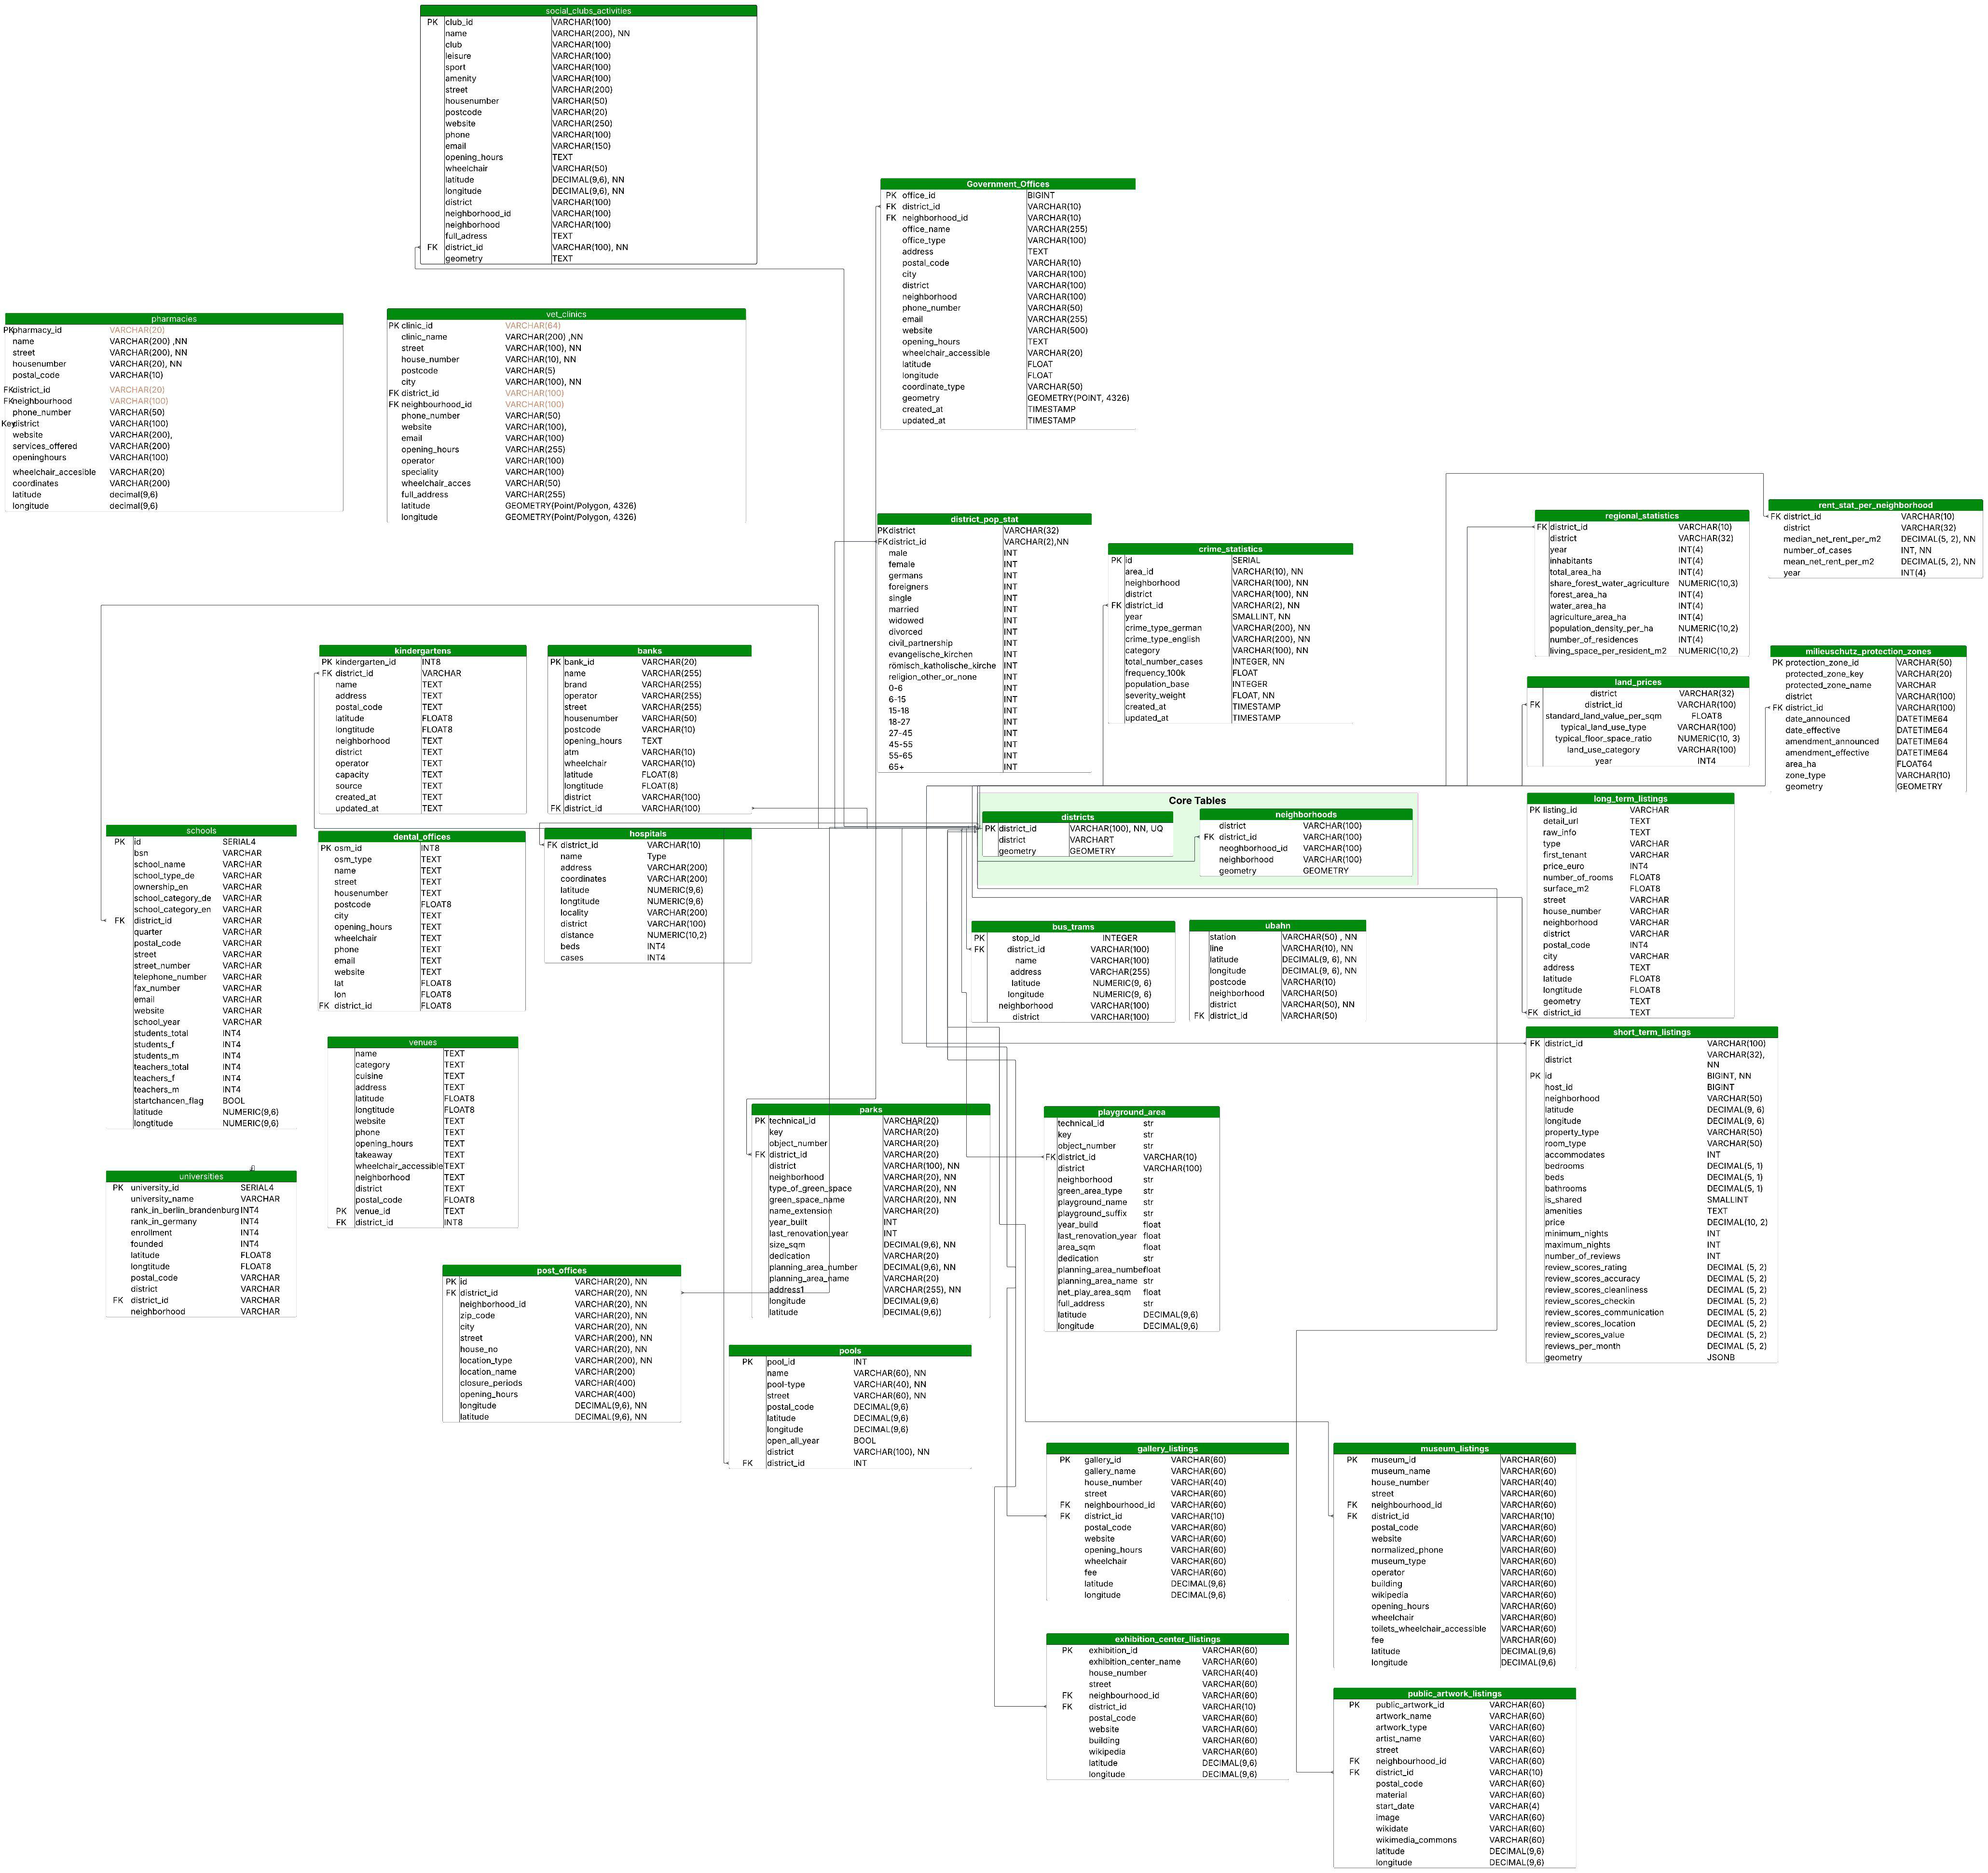

In [48]:
from PIL import Image

image_path = os.path.join("..", "sources", "Layered_ERD-Berlin.jpeg")
Image.open(image_path)